In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
OUT = os.path.join("..", "eda_outputs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join("..", "..", "data", "raw", "travel.csv"))
df.head()

,place_id,Place_Name,City,State,Zone,Place_Type,Interest_Tags,Suitable_For,Entry_Fee_INR,Activity_Cost_Min,...,Popularity_Rating,Number_Of_Reviewpoints,Best_Month_Start,Best_Month_End,Terrain_Type,Cluster_ID,Hidden_Gem_Score,Is_Hidden_Gem,Difficulty_Level,Typical_Duration
0,1,Dal Lake,Srinagar,Jammu And Kashmir,North,Lake,"Nature,Scenic,Relaxation","Couples,Family,Solo",0,500,...,4.3,4300,4,10,Valley,JAM-110,47.2,False,Easy,Full-day (4-8 hrs)
1,2,Shalimar Bagh,Srinagar,Jammu And Kashmir,North,Garden,"Historical,Cultural,Nature","Couples,Family,Solo",40,0,...,5.0,1000,4,10,Valley,JAM-110,92.4,True,Easy,Short (1-2 hrs)
2,3,Sonamarg,Ganderbal,Jammu And Kashmir,North,Valley,"Scenic,Adventure,Nature","Couples,Family,Friends,Solo",0,500,...,5.0,10000,5,9,Valley,JAM-110,81.4,True,Moderate,Full-day (4-8 hrs)
3,4,Gulmarg,Baramulla,Jammu And Kashmir,North,Hill Station,"Adventure,Scenic,Winter Sports","Couples,Family,Friends,Solo",0,700,...,5.0,10000,3,6,Mountain,JAM-110,81.4,True,Moderate,Full-day (4-8 hrs)
4,5,Noori Chamb Waterfall,Poonch,Jammu And Kashmir,North,Waterfall,"Nature,Scenic,Historic","Couples,Solo,Friends",0,0,...,4.0,700,4,10,Mountain,JAM-112,39.5,False,Moderate,Half-day (2-4 hrs)


In [2]:
report = []
report.append("# Voyexa AI — EDA Report\n")
report.append(f"Rows: **{df.shape[0]}**, Columns: **{df.shape[1]}**\n")
report.append(f"Missing values: **{df.isnull().sum().sum()}** (dataset is clean)\n")

print(df.shape)
df.isnull().sum()

(1163, 27)


place_id                    0
Place_Name                  0
City                        0
State                       0
Zone                        0
Place_Type                  0
Interest_Tags               0
Suitable_For                0
Entry_Fee_INR               0
Activity_Cost_Min           0
Activity_Cost_Max           0
HotelcostpernightINR_Min    0
HotelcostpernightINR_Max    0
FoodcostperdayINR_Min       0
FoodcostperdayINR_Max       0
Latitude                    0
Longitude                   0
Popularity_Rating           0
Number_Of_Reviewpoints      0
Best_Month_Start            0
Best_Month_End              0
Terrain_Type                0
Cluster_ID                  0
Hidden_Gem_Score            0
Is_Hidden_Gem               0
Difficulty_Level            0
Typical_Duration            0
dtype: int64

## 1. Places per State

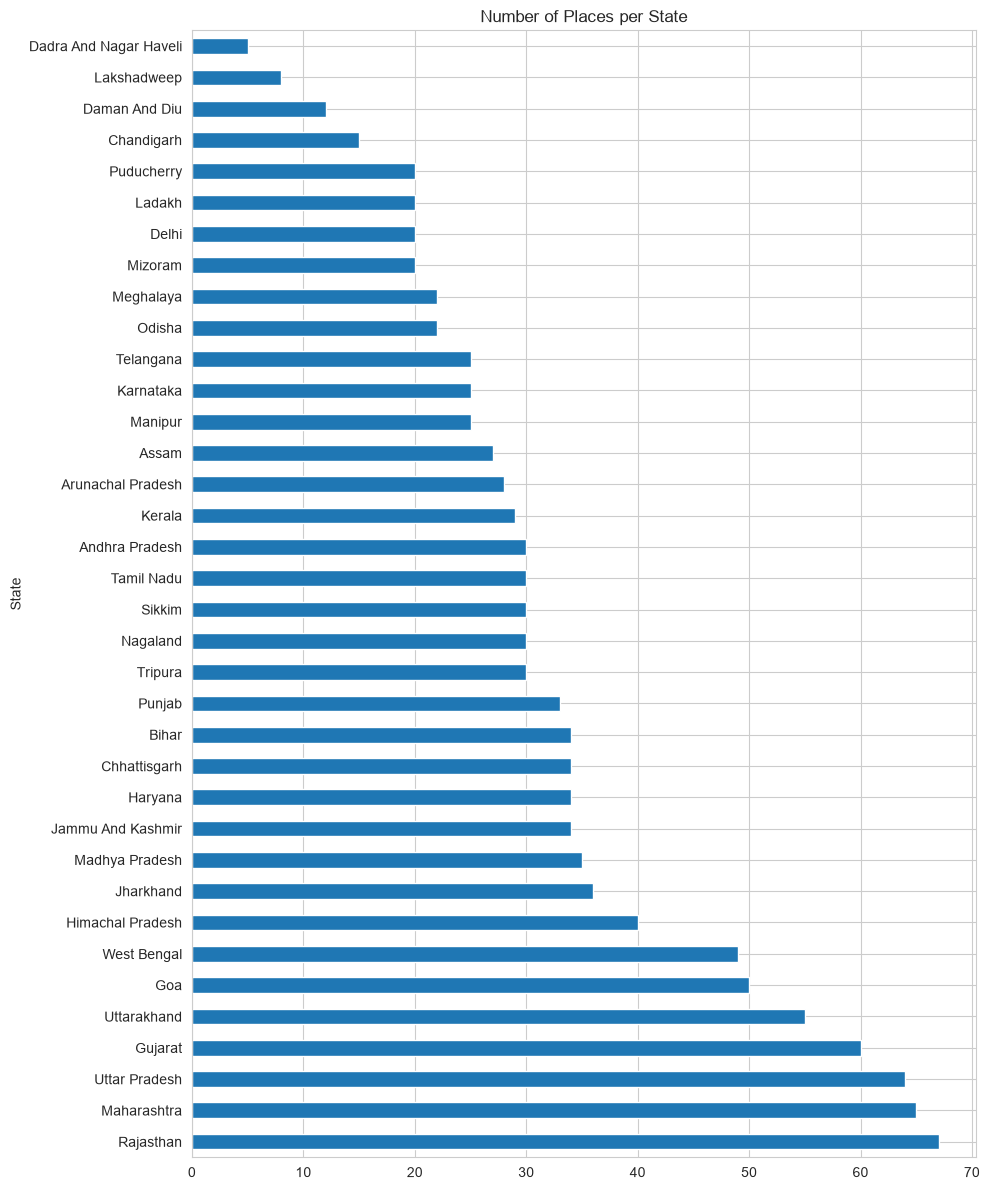

In [3]:
state_counts = df['State'].value_counts()
report.append("## Places per State\n")
report.append(f"Total states/UTs: {df['State'].nunique()}\n")
report.append(state_counts.to_frame('count').to_markdown() + "\n")

plt.figure(figsize=(10, 12))
state_counts.plot(kind='barh')
plt.title("Number of Places per State")
plt.tight_layout()
plt.savefig(f"{OUT}/places_per_state.png", dpi=120)
plt.show()

## 2. Zone Distribution

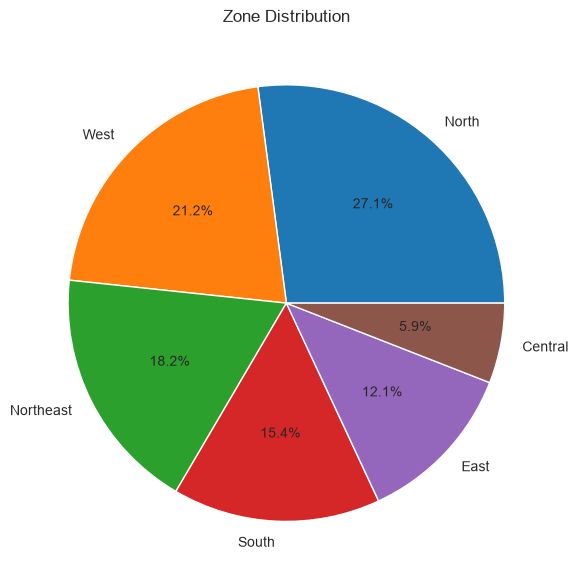

In [4]:
plt.figure(figsize=(6, 6))
df['Zone'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Zone Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{OUT}/zone_distribution.png", dpi=120)
plt.show()

## 3. Suitable_For Combinations (traveler type coverage)

In [5]:
suitable_counts = df['Suitable_For'].value_counts()
report.append("\n## Suitable_For Combinations (Top 10)\n")
report.append(suitable_counts.head(10).to_frame('count').to_markdown() + "\n")

for tag in ['Solo', 'Couples', 'Family', 'Friends']:
    df[f'is_{tag.lower()}'] = df['Suitable_For'].str.contains(tag, case=False, na=False)

report.append("\n### Individual traveler-type coverage\n")
for tag in ['Solo', 'Couples', 'Family', 'Friends']:
    n = df[f'is_{tag.lower()}'].sum()
    report.append(f"- {tag}: {n} places ({n/len(df)*100:.1f}%)\n")
    print(f"{tag}: {n} places ({n/len(df)*100:.1f}%)")

Solo: 398 places (34.2%)
Couples: 362 places (31.1%)
Family: 689 places (59.2%)
Friends: 561 places (48.2%)


## 4. Difficulty vs Terrain (safety filter validation)

<Figure size 800x500 with 0 Axes>

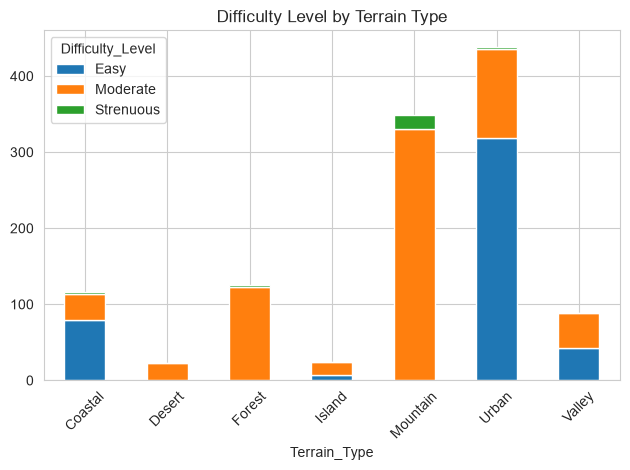

In [6]:
plt.figure(figsize=(8, 5))
pd.crosstab(df['Terrain_Type'], df['Difficulty_Level']).plot(kind='bar', stacked=True)
plt.title("Difficulty Level by Terrain Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT}/difficulty_by_terrain.png", dpi=120)
plt.show()

report.append("\n## Difficulty x Terrain (for age/health safety filter)\n")
report.append(pd.crosstab(df['Terrain_Type'], df['Difficulty_Level']).to_markdown() + "\n")

## 5. Cost Distributions (for budget model)

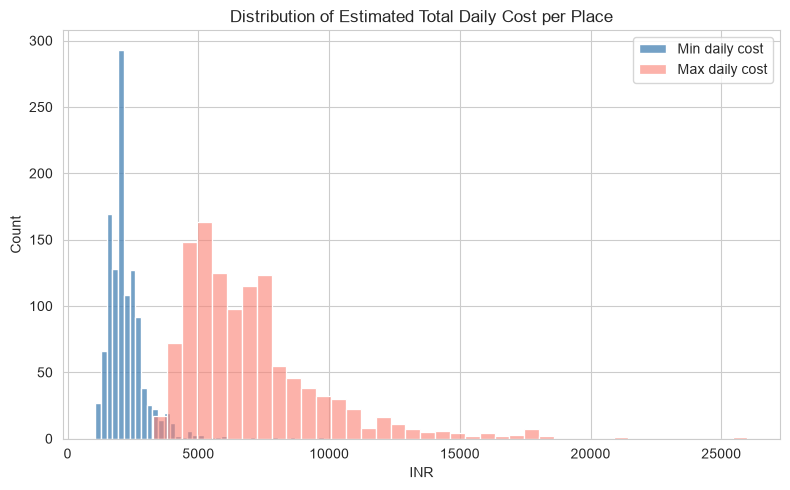

In [7]:
df['total_daily_cost_min'] = (df['Activity_Cost_Min'] + df['HotelcostpernightINR_Min'] +
                               df['FoodcostperdayINR_Min'] + df['Entry_Fee_INR'])
df['total_daily_cost_max'] = (df['Activity_Cost_Max'] + df['HotelcostpernightINR_Max'] +
                               df['FoodcostperdayINR_Max'] + df['Entry_Fee_INR'])

plt.figure(figsize=(8, 5))
sns.histplot(df['total_daily_cost_min'], bins=40, color='steelblue', label='Min daily cost')
sns.histplot(df['total_daily_cost_max'], bins=40, color='salmon', alpha=0.6, label='Max daily cost')
plt.legend()
plt.title("Distribution of Estimated Total Daily Cost per Place")
plt.xlabel("INR")
plt.tight_layout()
plt.savefig(f"{OUT}/cost_distribution.png", dpi=120)
plt.show()

report.append("\n## Estimated Daily Cost (Entry + Activity + Hotel + Food)\n")
report.append(df[['total_daily_cost_min', 'total_daily_cost_max']].describe().to_markdown() + "\n")

### Average Daily Cost per State (for budget ranking layer)

In [8]:
state_cost = df.groupby('State')[['total_daily_cost_min', 'total_daily_cost_max']].mean().sort_values('total_daily_cost_min')
report.append("\n## Average Daily Cost per State (for budget ranking)\n")
report.append(state_cost.round(0).to_markdown() + "\n")
state_cost

,total_daily_cost_min,total_daily_cost_max
State,,
Andhra Pradesh,1598.833333,5708.833333
Tamil Nadu,1627.666667,5936.000000
Punjab,1648.787879,5527.575758
Bihar,1678.970588,4949.558824
Karnataka,1776.600000,6304.600000
Telangana,1788.000000,6072.000000
Uttar Pradesh,1817.500000,6305.000000
Manipur,1863.200000,7335.200000
Mizoram,1870.500000,4375.500000


## 6. Popularity & Hidden Gems

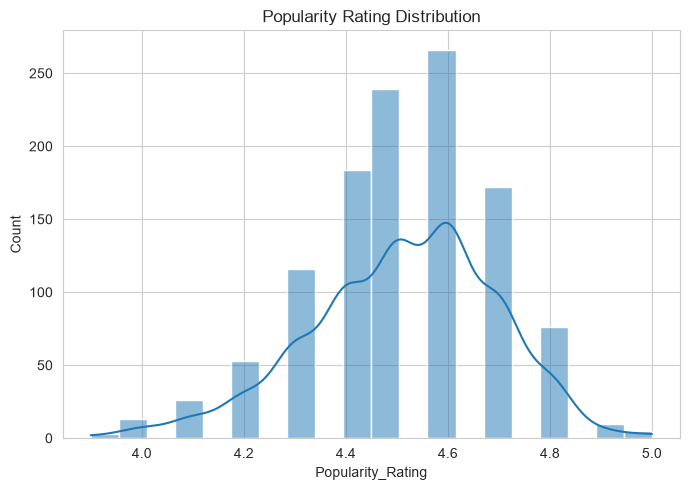

In [9]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Popularity_Rating'], bins=20, kde=True)
plt.title("Popularity Rating Distribution")
plt.tight_layout()
plt.savefig(f"{OUT}/popularity_distribution.png", dpi=120)
plt.show()

report.append("\n## Popularity & Hidden Gems\n")
report.append(f"- Avg Popularity_Rating: {df['Popularity_Rating'].mean():.2f}\n")
report.append(f"- Hidden gems: {df['Is_Hidden_Gem'].sum()} ({df['Is_Hidden_Gem'].mean()*100:.1f}%)\n")

## 7. Seasonality (Best Month coverage)

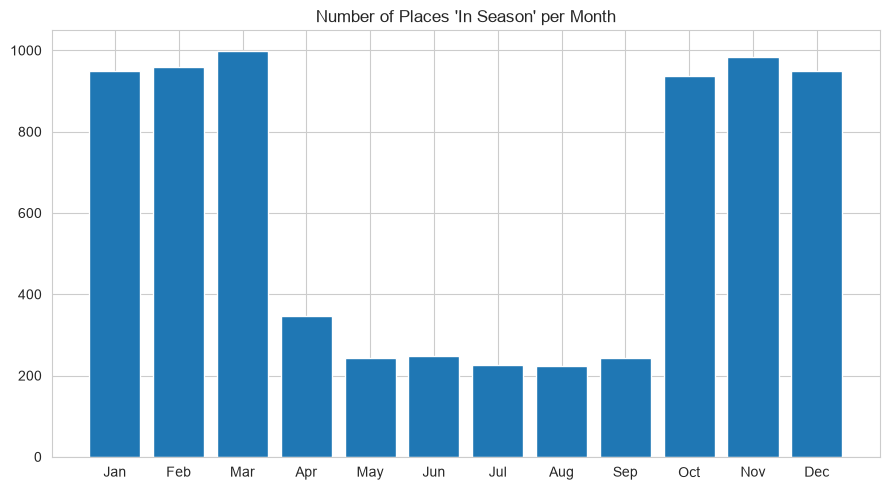

In [10]:
month_open = [0]*13
for _, row in df.iterrows():
    s, e = row['Best_Month_Start'], row['Best_Month_End']
    months = list(range(s, e+1)) if s <= e else list(range(s, 13)) + list(range(1, e+1))
    for m in months:
        month_open[m] += 1

plt.figure(figsize=(9, 5))
plt.bar(range(1, 13), month_open[1:])
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Number of Places 'In Season' per Month")
plt.tight_layout()
plt.savefig(f"{OUT}/seasonality.png", dpi=120)
plt.show()

report.append("\n## Seasonality (places in-season per month)\n")
for m, cnt in enumerate(month_open):
    if m == 0: continue
    report.append(f"- Month {m}: {cnt} places\n")

## 8. Top Interest Tags

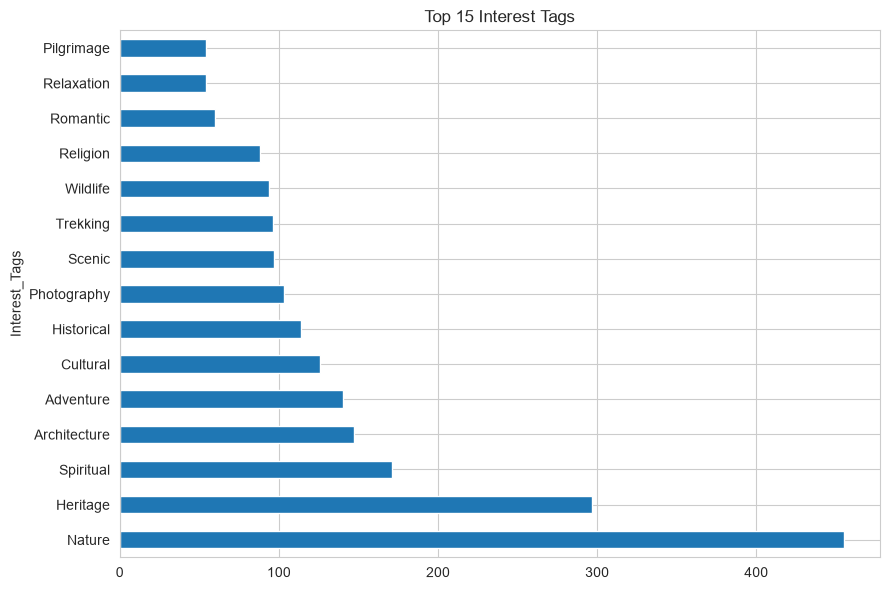

In [11]:
all_tags = df['Interest_Tags'].str.split(',').explode().str.strip()
tag_counts = all_tags.value_counts()
report.append("\n## Top Interest Tags\n")
report.append(tag_counts.head(15).to_frame('count').to_markdown() + "\n")

plt.figure(figsize=(9, 6))
tag_counts.head(15).plot(kind='barh')
plt.title("Top 15 Interest Tags")
plt.tight_layout()
plt.savefig(f"{OUT}/top_interest_tags.png", dpi=120)
plt.show()

## 9. Correlation Heatmap (cost & popularity fields)

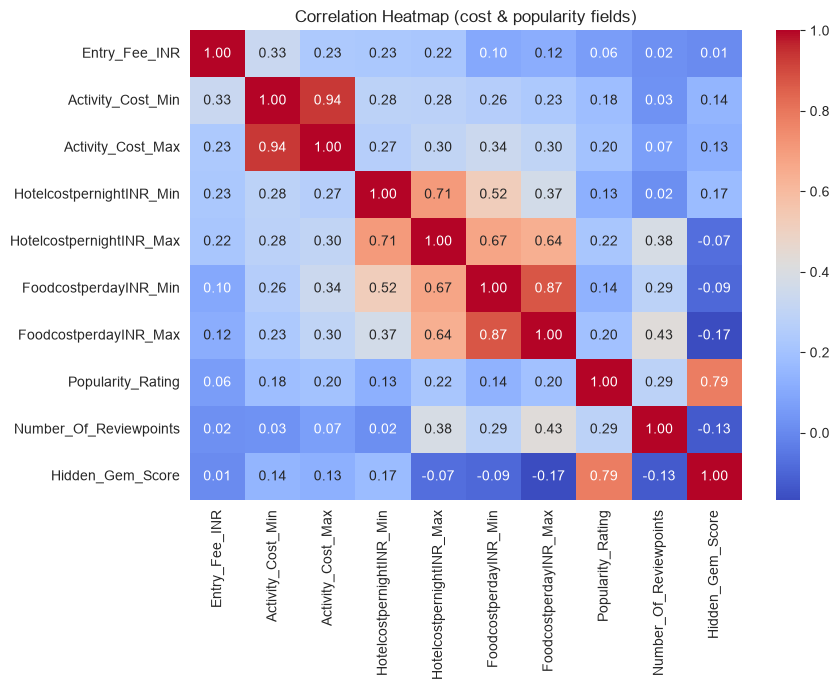

In [12]:
num_cols = ['Entry_Fee_INR','Activity_Cost_Min','Activity_Cost_Max',
            'HotelcostpernightINR_Min','HotelcostpernightINR_Max',
            'FoodcostperdayINR_Min','FoodcostperdayINR_Max',
            'Popularity_Rating','Number_Of_Reviewpoints','Hidden_Gem_Score']
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap (cost & popularity fields)")
plt.tight_layout()
plt.savefig(f"{OUT}/correlation_heatmap.png", dpi=120)
plt.show()

In [13]:
with open(f"{OUT}/eda_report.md", "w") as f:
    f.write("\n".join(report))

print("EDA complete. Report + charts saved in ml/eda_outputs/")

EDA complete. Report + charts saved in ml/eda_outputs/
